In [32]:
using Oceananigans
using NCDatasets
using Printf
using CairoMakie
using Oceananigans.Fields
using Oceananigans.AbstractOperations: volume
using NaNStatistics

In [33]:
using TopographicHorizontalConvection
using TopographicHorizontalConvection: HorizontalConvectionSimulation

In [34]:
ds_buoy = NCDataset("/pub/ikeshwan/code/HorizontalConvection/output/turbulent_h0.6_Ra1.0e8_coldstart_buoyancy.nc");
ds_vel = NCDataset("/pub/ikeshwan/code/HorizontalConvection/output/turbulent_h0.6_Ra1.0e8_coldstart_velocities.nc");

# Calculation of Fluxes

#### Reversible Vertical Buoyancy Flux:  
$ \phi_z = \int \rho g w dV \rightarrow -\int b w dV $

#### Rate of conversion from internal to potential energy:   
$ \phi_i = -\kappa g A (\bar{\rho}_{top} - \bar{\rho}_{bottom})$

#### Rate of change of background potential due to diapycnal mixing : 
$ \phi_d = \kappa g \int - \frac{dz_*}{d \rho} \left | \nabla \rho \right |^2 dV$

In [35]:
#vertical buoyancy flux

b = ds_buoy["b"][4+1:end-4, 1, 4+1:end-4, :];
w = ds_vel["w"][4+1:end-4, 1, 5+1:end-4, :];

bw = b .* w;

bw = reshape(bw, Nx, 1, Nz, length(time));

In [36]:
#integrate bw over volume -- reimann sum

x = ds_buoy["xC"][4+1:end-4]; Nx = length(x);
z = ds_buoy["zC"][4+1:end-4]; Nz = length(z);
time = ds_buoy["time"][:];
Δx = reshape(diff(ds_buoy["xF"])[4+1:end-4], Nx,1,1);
Δz = reshape(diff(ds_buoy["zF"])[4+1:end-4], 1, 1, Nz);
ΔA = Δx;
ΔV = ΔA .* Δz
ϕ_z = zeros(size(time,1));

for n in 1:size(time, 1)
    bw_t = - bw[:, 1, :, n]
    wet = bw_t.!=0
    bw_t[.!wet] .= NaN
    ϕ_z[n] = nansum(
        bw_t .*
        ΔV, 
        dims=(3)
        )[1,1,1]
end

ϕ_z;

### Next, let's calculate $\phi_i$

#### Rate of conversion from internal to potential energy:   
$ \phi_i = -\kappa g A (\bar{\rho}_{top} - \bar{\rho}_{bottom}) \rightarrow \kappa A (b_{top} - b_{bottom}) $

In [44]:
b_bottom = TopographicHorizontalConvection.buoyancy_level_avg(ds_buoy, "bottom");
b_top = TopographicHorizontalConvection.buoyancy_level_avg(ds_buoy, "top");
#I cant seem to figure out how to access global attributes from NetCDF files, but upon looking at ds_buoy we know kappa=0.0001
κ = 0.0001;
A = 8

ϕᵢ = κ * A * (b_top .- b_bottom);

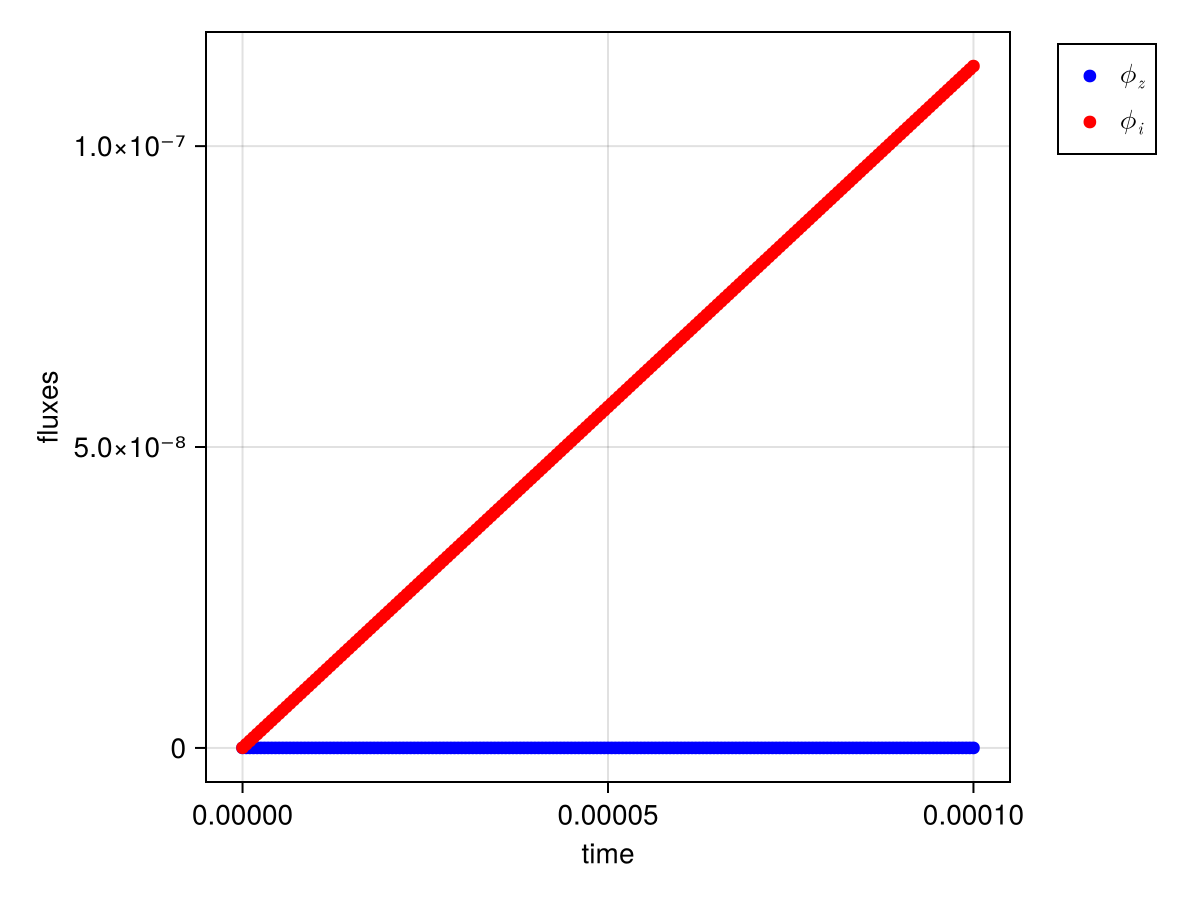

In [57]:
f = Figure()
ax = Axis(f[1,1], xlabel = "time", ylabel= "fluxes")
scatter!(ax, time, ϕ_z, color = "blue", label = L"\phi_z")
scatter!(ax, time, ϕᵢ, color = "red", label = L"\phi_i")
f[1,2] = axislegend()
f

### Now for the hard one, $ \phi_d $

#### Rate of change of background potential due to diapycnal mixing : 
$ \phi_d = \kappa g \int - \frac{dz_*}{d \rho} \left | \nabla \rho \right |^2 dV$